In [1]:
import torch 
import torch.nn as nn

import numpy as np

from basemodel import *

from data_handler import *

from optimizer import *

from fit import *

import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import *

import cbs

from unet import Unet_sigmoid

from collections import OrderedDict

import unet_ein as ue

def save(path,results,names = ['normal','attack','disable','end','test']):
    for i in range(len(results)):
        np.save(path+names[i]+'.npy',results[i])

import random

import pytorch_ssim

# Data

In [16]:
trn_ , val_ = split('../dataset/fuz attack/lka_can/normal/bin/',prc = 0.2, dataset_pct=  1, dim =(112,112), word_type=torch.float)
atk , _ = split('../dataset/fuz attack/lka_can/attack/bin/',prc = 0 , dataset_pct=  1, dim = (112,112), word_type=torch.float)

In [17]:
trn_.data= trn_.data[80*220:]

In [18]:
atk.data = trn_.data + val_.data+ atk.data

In [19]:
bs = 8
seq_len = 10
overlap=0

In [20]:
trn_dl = Sequence_dl( trn_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[112,112])
v4_val_dl = Sequence_dl( val_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[112,112])

In [21]:
v4_anml_dl = Sequence_dl( atk, bs=bs,seq_len=seq_len,overlap =overlap,num_workers=4,drop_last=True,dim=[112,112])

In [22]:
dl =CombineDataLoader(trn_dl,v4_val_dl)

# Custom Loss

In [23]:
class SSIM:
    def __init__(self):
        self.ssim_loss = pytorch_ssim.SSIM(window_size = 11)
    def __call__(self,ip,tgt):
        
        if type(ip[-1]) == torch.Tensor:
            tgt_lka,tgt_vis,ip_lka,ip_vis,tgt_hist,ip_hist = ip
            
            tgt_vis = tgt_vis [None,None,None,:]
            ip_vis = ip_vis [None,None,None,:]
            tgt_hist = tgt_hist [None,None,:,:]
            ip_hist = ip_hist [None,None,:,:]
            
            
            vis = self.ssim_loss(ip_vis,tgt_vis)
            lka = 0#nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
            hist = self.ssim_loss(ip_hist,tgt_hist)

            return 1 - (lka+vis*0.5+hist*0.5)            
        
        else:
            tgt_lka,tgt_vis,ip_lka,ip_vis,_,_ = ip
            
            tgt_vis = tgt_vis [None,None,None,:]
            ip_vis = ip_vis [None,None,None,:]

            
            vis = self.ssim_loss(ip_vis,tgt_vis)
            lka = 0#nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
            
            return 1 - (lka+vis)
        

In [24]:
class binary:
    def __call__(self,ip,tgt):     
        if type(ip[-1]) == torch.Tensor:
            tgt_lka,tgt_vis,ip_lka,ip_vis,tgt_hist,ip_hist = ip
           
            vis = nn.functional.binary_cross_entropy(ip_vis[:88],tgt_vis[:88])
            lka = 0#nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
            hist = nn.functional.binary_cross_entropy(ip_hist,tgt_hist)
    
            return torch.pow((lka+vis*0.5+hist*0.5),2)            
        
        else:
            tgt_lka,tgt_vis,ip_lka,ip_vis,_,_ = ip
            
            vis = nn.functional.binary_cross_entropy(ip_vis[:88],tgt_vis[:88])
            lka = 0#nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
            
            return (lka+vis)

In [25]:
class mse:
    def __call__(self,ip,tgt):
        if type(ip[-1]) == torch.Tensor:
            tgt_lka,tgt_vis,ip_lka,ip_vis,tgt_hist,ip_hist = ip
            
            vis = nn.functional.mse_loss(ip_vis[:88],tgt_vis[:88])
            lka = 0#nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
            hist = nn.functional.mse_loss(ip_hist,tgt_hist)

            return torch.sqrt(lka+vis*0.5+hist*0.5)            
        
        else:
            tgt_lka,tgt_vis,ip_lka,ip_vis,_,_ = ip
            
            vis = nn.functional.mse_loss(ip_vis[:88],tgt_vis[:88])
            lka = 0#nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
            
            return (lka+vis)

In [26]:
loss = mse()

## Helping Methods

In [27]:
def get_vis(frame):
    new_frame = frame.type(torch.int).tolist()
    new_frame = [str(i) for i in new_frame]
    s = ''.join(new_frame)
    new_frame = s[-4:] + s[:8]
    
    return (int(new_frame,2) *0.01)-16

In [28]:
def get_frame(value):
    
    value = int((value +16 ) / 0.01)
    
    hex_value = hex(value)[2:]
    bin_value = bin(int(f"{hex_value}", 16))[2:].zfill(12)
    
    new_frame = bin_value[-8:] + bin_value[:4]
    new_frame = [float(i) for i in list(new_frame)]
    new_frame = torch.tensor(new_frame)
    return new_frame

In [29]:
vis = np.load('../dataset/fuz attack/generated_ds/amr/array.npy')

# Model : Predict LKA
Input: VIS History + Previous VIS + VIS <br>
Input Form: Full frame<br>
Output: Prediction   LKA <br>
Training Dataset: Original<br>

In [52]:
# 8 epoch 
#lr 1e-4
#bce
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        
        self.vis = torch.tensor([0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0.,
         0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0.,
         0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1.]).cuda()
        self.lka = torch.zeros(88).cuda()
        
        self.history_reconstruct_conv = nn.Conv1d(1,200,(1,))
        
        self.lka_compressor = nn.Sequential(nn.Linear(88*3,1024*1),
                                            nn.PReLU(),
                                            nn.Dropout(0.4),
                                            nn.Linear(1024,1024*1),
                                            nn.PReLU(),
                                            nn.Dropout(0.4),
                                            nn.Linear(1024*1,88),
                                            nn.Sigmoid())
        
        
        self.history_reconstruct = nn.Sequential(self.history_reconstruct_conv,
                                                 nn.Sigmoid())
        
        self.drop = nn.Dropout(0.1)
        self.previous_lka = torch.zeros(88).cuda()
        self.previous_states = torch.zeros(88).cuda()
        self.flag_list = []
        self.predection = []
        self.previous_states_conv = nn.Conv1d(2,1,(1))
        
        self.previous_vis = []
        self.state_list = []
        self.vis_value = 0
        
        self.c =0
        self.art_lka = []
        self.test = True
        self.max_count= 2352
        self.count = 0
        self.gen_vis = []
        
        
    def forward(self,x):   
        #torch.manual_seed(0)
        #self.lka = torch.zeros(88).cuda()
        input_list = x.view(80,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:208] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size and not self.test :
            self.count = (self.count+1)%836
            self.vis = x.view(80,-1)[vis_idx[0]][120:208]
            #self.vis_value = get_vis(self.vis[28:28+16].data)
            
            self.vis_value = self.gen_vis[self.count]            
            
            self.vis.data[28:28+8] = get_frame(self.vis_value)[:8].data.cuda()
            self.vis.data[28+12:28+16] = get_frame(self.vis_value)[-4:].data.cuda()
            self.vis_value = get_vis(self.vis[28:28+16].data)
            
        elif vis_idx.size:   
            self.count = (self.count+1)%836
            self.vis = x.view(80,-1)[vis_idx[0]][120:208]
            self.vis_value = get_vis(self.vis[28:28+16].data)
            if self.c > 2050 and self.c <2450:
            #    print(self.count)
            #    self.vis_value = self.vis_value - 1
                self.vis.data[28:28+8] = get_frame(self.vis_value)[:8].data.cuda()
                self.vis.data[28+12:28+16] = get_frame(self.vis_value)[-4:].data.cuda()
                
        if self.c==0 and not self.test:
            
            self.art_lka = []
            idx = random.randint(0,3)
            self.art_lka.extend( torch.randint(0,400,(1,(idx*2)+1)).tolist()[0])
            self.art_lka.extend( torch.randint(740,850,(1,random.randint(0,2))).tolist()[0])
            #self.art_lka.extend( torch.randint(510,570,(1,random.randint(0,2))).tolist()[0])
            print(self.art_lka)
            

        if self.c in self.art_lka:
            print('fake')
            self.lka =torch.logical_xor(self.lka.type(torch.BoolTensor),torch.ones_like(self.lka).type(torch.BoolTensor)).type(torch.FloatTensor).cuda()

        
        #Get the history of vis from previous vis and all the past frames
        history = self.previous_states_conv(torch.stack([self.previous_states,self.vis]).view(1,2,-1)).view(-1)
        history = self.drop(nn.functional.relu(history))
        predected_lka = self.lka_compressor(self.drop(torch.cat([self.previous_lka,history,self.vis])))
        
        
        if self.c > 200:
            predicted_hist = (self.history_reconstruct(history.view(1,1,-1)).view(200,-1))[:,28+4:28+16]
            actual_hist = (torch.stack(self.state_list[-200:]).view(200,-1))[:,28+4:28+16].cuda()
            
        else:
            predicted_hist = None
            actual_hist = None
            
        self.previous_lka = self.lka.detach().data
        self.previous_states = history.detach().data
        
        
        self.previous_vis.append(self.vis.detach().cpu().data)
        self.state_list.append(history.detach().cpu().data)
        
            
        
        self.flag_list.append([self.lka.detach().cpu(),self.vis.detach().cpu(),self.vis_value])
        self.c = (self.c + 1) % self.max_count
        return self.vis.type(torch.FloatTensor).cuda(),self.lka.type(torch.FloatTensor).cuda(),None,predected_lka,actual_hist,predicted_hist


In [30]:
import random


In [31]:
# 4 epoch 
#lr 1e-4
#mse
#parameter size = 1054746
#inference time = 7.576181157394465 ms/ mb
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        
        self.vis = torch.tensor([0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0.,
         0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0.,
         0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1.]).cuda()
        self.lka = torch.zeros(1).cuda()
        
        self.history_reconstruct_conv = nn.Conv1d(1,10,(1,))
        
        #self.dec_lin = nn.Sequential(nn.Linear(1,88),
        #                                    nn.PReLU(),)
        
        self.lka_compressor = nn.Sequential(nn.Linear(3,1024*1),
                                            nn.PReLU(),
                                            nn.Dropout(0.4),
                                            nn.Linear(1024,1024*1),
                                            nn.PReLU(),
                                            nn.Dropout(0.4),
                                            nn.Linear(1024*1,1),
                                            nn.Sigmoid())
        
        
        self.history_reconstruct = nn.Sequential(self.history_reconstruct_conv,
                                                 nn.Sigmoid())
        
        self.drop = nn.Dropout(0.1)
        self.previous_lka = torch.zeros(1).cuda()
        self.previous_states = torch.zeros(1).cuda()
        self.flag_list = []
        self.predection = []
        self.previous_states_conv = nn.Conv1d(2,1,(1))
        
        self.previous_vis = []
        self.state_list = []
        self.vis_value = 0
        
        self.c =0
        self.art_lka = []
        self.test = True
        self.max_count= 2352
        self.count = 0
        self.gen_vis = []
        
        
    def forward(self,x):   
        #torch.manual_seed(0)
        self.lka = torch.zeros(1).cuda()
        input_list = x.view(80,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:208] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size and not self.test :
            self.count = (self.count+1)%836            
            self.vis_value = self.gen_vis[self.count] /4           

            
        elif vis_idx.size:   
            self.count = (self.count+1)%836
            self.vis = x.view(80,-1)[vis_idx[0]][120:208]
            self.vis_value = get_vis(self.vis[28:28+16].data)/4
            
                
        if self.c==0 and not self.test:
            
            self.art_lka = []
            idx = random.randint(0,8)
            self.art_lka.extend( torch.randint(0,400,(1,(idx*2)+1)).tolist()[0])
            self.art_lka.extend( torch.randint(740,850,(1,random.randint(0,6))).tolist()[0])
            #self.art_lka.extend( torch.randint(510,570,(1,random.randint(0,2))).tolist()[0])
            print(self.art_lka)
            

        if self.c in self.art_lka:
            print('fake')
            self.lka =torch.logical_xor(self.lka.type(torch.BoolTensor),torch.ones_like(self.lka).type(torch.BoolTensor)).type(torch.FloatTensor).cuda()

        #Get the history of vis from previous vis and all the past frames
        self.vis_value = torch.tensor(self.vis_value).view(1,).type(torch.FloatTensor).cuda() 
        history = self.previous_states_conv(torch.stack([self.previous_states,self.vis_value]).view(1,2,-1)).view(-1)
        history = self.drop(nn.functional.relu(history))
        predected_lka = self.lka_compressor(self.drop(torch.cat([self.previous_lka,history,self.vis_value])))
        
        
        if self.c > 10:
            predicted_hist = (self.history_reconstruct(history.view(1,1,-1)).view(10,-1))
            actual_hist = (torch.stack(self.state_list[-10:]).view(10,-1)).cuda()
            
        else:
            predicted_hist = None
            actual_hist = None
            
        self.previous_lka = self.lka.detach().data
        self.previous_states = history.detach().data
        
        
        self.previous_vis.append(self.vis.detach().cpu().data)
        self.state_list.append(self.vis_value.detach().cpu().data)
        
            
        
        self.flag_list.append([self.lka.detach().cpu(),self.vis.detach().cpu(),self.vis_value])
        self.c = (self.c + 1) % self.max_count
        return self.vis.type(torch.FloatTensor).cuda(),self.lka.type(torch.FloatTensor).cuda(),None,predected_lka,actual_hist,predicted_hist


In [79]:
m =  unet_seq(bs,seq_len).cuda()

In [80]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [81]:
trn_item = Validate(trn_dl)
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [82]:
m.gen_vis = np.load('../dataset/fuz attack/generated_ds/amr/array.npy')
m.test = False
m.max_count = len(trn_dl)+len(v4_val_dl)

In [83]:
loss =mse()

In [84]:
cbs.load_all('publication/recon_hist_dec_vis/',model=m,opt=opt,learn=learn)
#cbs.load_all('publication/predict lka with dec vis/mse/',model=m,opt=opt,learn=learn)

In [85]:
#learn.fit(m , opt , 4 , dl,loss  )

In [86]:
m.test = True
m.max_count =  len(v4_anml_dl)
m.lka = torch.zeros(1).cuda()
m.vis = torch.tensor([0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0.,
         0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0.,
         0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1.]).cuda()
l1 = range(250,3500,100)
l = [[],[400],[250,400,1000,2400],[1000,1500],[1500],[2400],l1]
m.art_lka = l[-1]#range(0,3500,50)
m.b = 0

In [87]:
%%time
#trn_item.evaluate(model = m , crit = loss)
#val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

/home/amr/.local/lib/python3.6/site-packages/ipykernel_launcher.py:93: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  0%|          | 9/3577 [00:00<00:45, 79.19it/s]

testing...


  8%|▊         | 269/3577 [00:02<00:25, 130.15it/s]

fake


 10%|█         | 364/3577 [00:02<00:24, 129.46it/s]

...

fake


 97%|█████████▋| 3476/3577 [00:26<00:00, 133.20it/s]

fake


100%|█████████▉| 3574/3577 [00:26<00:00, 136.24it/s]

CPU times: user 16.8 s, sys: 2.5 s, total: 19.3 s
Wall time: 26.9 s


In [88]:
#a = torch.tensor(val2_item.test_loss)#.median() # Validation
d = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
#c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

In [89]:
c==d

tensor([False, False, False,  ..., False, False, False])

In [74]:
#index 203735 in the sheet

In [75]:
lka = [i[0][0]for i in m.flag_list]
vis = [i[-1]for i in m.flag_list]

In [76]:
n = 3

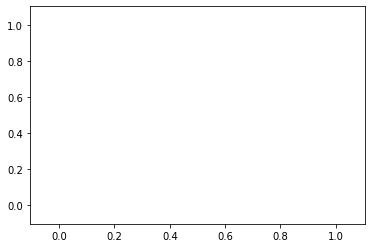

In [77]:
fig,ax = plt.subplots()
#ax.plot(range(len(b)),list(b),label='train')
#ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
#ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

#ax.plot(range(len(vis[-3576:])),vis[-3576:],label='lka')
#ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
ax.plot(range(len(vis[2352*n:2352*(n+1)])),vis[2352*n:2352*(n+1)],label='lka')
ax.plot(range(len(lka[2352*n:2352*(n+1)])),lka[2352*n:2352*(n+1)],label='lka')
#ax.plot(range(len(vis[2352*n:2352*(n+1)])),s,label='lka')
#ax.legend()

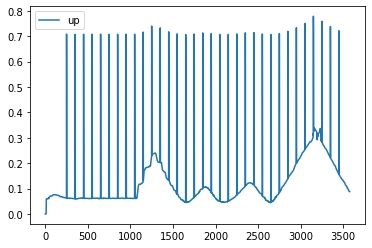

In [94]:
fig,ax = plt.subplots()
#ax.plot(range(len(b)),list(b),label='train')
#ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
#ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')


#plt.xticks([], vis)
#plt.yticks([], vis)
#ax.plot(range(len(vis[-3576:])),vis[-3576:],label='vis')
#ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
#ax.plot(range(len(b)),b,label='norm')
ax.plot(range(len(d)),d,label='up')
#ax.plot(range(len(lka)),lka,label='lka')
ax.legend()


In [75]:
#fig.savefig('Models/publication/recon_hist_vis/bce/15/i.png',dpi=300)

In [145]:
#np.save('Models/publication/recon_hist_vis/bce/15/attack.npy',c)

In [146]:
c[:1000].max()

tensor(0.9729)

In [147]:
#fig.savefig('Documents/case7.png')

In [149]:
c[350]

tensor(0.5905)

In [47]:
b=c

In [48]:
c = 0
l = []
for i in b:
    c+=1
    if  i > 0.2 :
        l.append(i)


In [49]:
len(l)

37

In [50]:
l = l[0::2]

In [53]:
q=np.array(l)[0:5].max()
w=np.array(l)[0:5].min()

In [54]:
(np.array(l) <= q) == (np.array(l) >= w)

array([ True,  True,  True,  True,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False])

In [55]:
c = 0
l = []
for i in b:
    c+=1
    if  i > 0.2 :
        l.append(i)


In [56]:
l = l[1::2]

In [57]:
r=np.array(l)[0:4].max()
t=np.array(l)[0:4].min()

In [58]:
(np.array(l) <= r) == (np.array(l) >= t)

array([ True,  True,  True,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False])

In [59]:
cbs.save_all('Models/publication/recon_hist_dec_vis/',learn = learn,model=m ,opt=opt)

In [343]:
loss = mse()

In [43]:
lka_list = []
vis_list = []
op_list = []
for i in range(1,8,1):
    m =  unet_seq(bs,seq_len).cuda()
    cbs.load_all('publication/predict lka with dec vis/mse/',model=m,opt=opt,learn=learn)
    m.test = True
    m.max_count = len(v4_anml_dl)
    m.vis = torch.tensor([0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0.,
         0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0.,
         0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1.]).cuda()
    m.art_lka = l[i-1]
    
    v4_anml_item.evaluate(model = m , crit = loss)
    op_list.append( torch.tensor(v4_anml_item.test_loss))#.median() # Anomaly 
   
    lka_list.append([i[0][0]for i in m.flag_list])
    vis_list.append([i[-1]for i in m.flag_list])
    
    #fig,ax = plt.subplots()
    #ax.plot(range(len(b)),list(b),label='model op')
    

    #ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
    #ax.plot(range(len(vis[-3576:])),vis[-3576:],label='vis')
    #ax.plot(range(len(lka)),lka,label='lka')
    #ax.legend()

    
    #path = f'Models/publication/recon_hist_dec_vis/mse/{i}/'
    #fig.savefig(f'{path}i.png',dpi=300,,bbox_inches = 'tight',pad_inches=0.1)
    #save(path,[b],names=['attack'])

/home/amr/.local/lib/python3.6/site-packages/ipykernel_launcher.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  0%|          | 4/3577 [00:00<01:44, 34.17it/s]

testing...


  0%|          | 3/3577 [00:00<02:08, 27.92it/s]/s]

testing...


 11%|█▏        | 409/3577 [00:05<00:42, 74.02it/s]

...

 94%|█████████▍| 3368/3577 [00:24<00:01, 140.98it/s]

fake


 97%|█████████▋| 3470/3577 [00:24<00:00, 140.63it/s]

fake


100%|█████████▉| 3572/3577 [00:25<00:00, 139.75it/s]

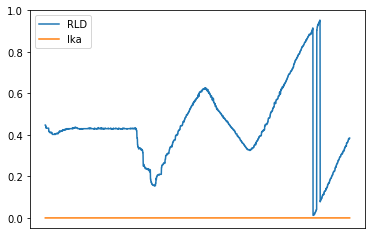

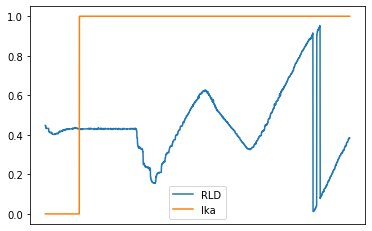

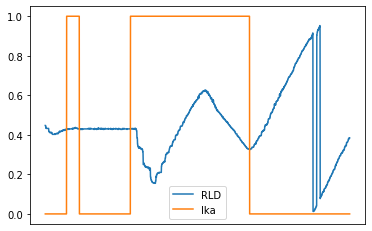

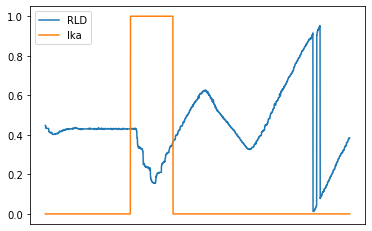

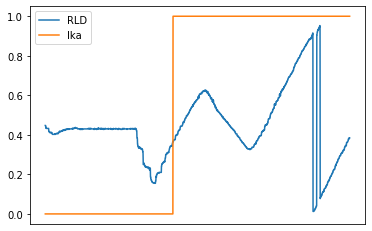

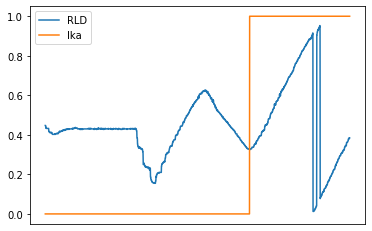

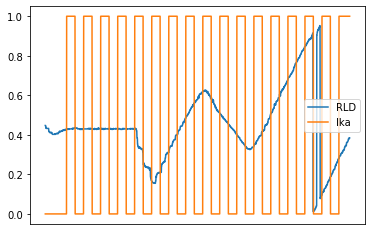

In [45]:
d = 1
#label = ['a','b','c','d','e','f','g','h','i']
for i in range(len(op_list)):
    fig,ax = plt.subplots()
    plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off
    
    
    #plt.xlabel(f'({label[i-1]})',fontsize=18)
    #plt.yticks(ticks=[])
    #ax.plot(range(len(op_list[i][1:])),list(op_list[i][1:]),label='model op')
    ax.plot(range(len(vis_list[i][1:])),vis_list[i][1:],label='RLD')
    ax.plot(range(len(lka_list[i])),lka_list[i],label='lka')
    ax.legend()
    path = 'Models/publication/predict lka with dec vis/mse/'
    fig.savefig(f'{i}.png' , format = 'png' , dpi=300,bbox_inches = 'tight',pad_inches=0.1)
    #np.save(f'{path}{d+i}/attack.npy',op_list[i])

# LKA predictor

# Model : Predict LKA
Input: VIS History + Previous VIS + VIS <br>
Input Form: Full frame<br>
Output: Prediction   LKA <br>
Training Dataset: Original<br>

In [ ]:
# 16 epoch 
#lr 1e-4
#bce

class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        
        self.vis = torch.ones(88).cuda()
        self.lka = torch.zeros(88).cuda()
        
        self.history_reconstruct_conv_1 = nn.Conv1d(1,50,(1,))
        self.history_reconstruct_conv_2 = nn.Conv1d(50,200,(1,))
        
        self.lka_compressor = nn.Sequential(nn.Linear(88*3,1024*1),
                                            nn.PReLU(),
                                            nn.Dropout(0.6),
                                            nn.Linear(1024,1024*1),
                                            nn.PReLU(),
                                            nn.Dropout(0.6),
                                            nn.Linear(1024*1,88),
                                            nn.Sigmoid())
        
        
        self.history_reconstruct = nn.Sequential(self.history_reconstruct_conv_1,
                                                 self.history_reconstruct_conv_2,
                                                 nn.Sigmoid())
        
        self.drop = nn.Dropout(0.1)
        self.previous_lka = torch.zeros(88).cuda()
        self.previous_states = torch.zeros(88).cuda()
        self.flag_list = []
        self.predection = []
        self.previous_states_conv = nn.Conv1d(2,1,(1))
        
        self.previous_vis = []
        self.state_list = []
        self.vis_value = 0
        
        self.c =0
        self.art_lka = []
        self.test = True
        self.max_count= 2352
        self.count = 0
        self.gen_vis = []
    def forward(self,x):        
        #self.lka = torch.zeros(88).cuda()
        input_list = x.view(80,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:208] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size and not self.test :
            self.count = (self.count+1)%836
            self.vis = x.view(80,-1)[vis_idx[0]][120:208]
            #self.vis_value = get_vis(self.vis[28:28+16].data)
            
            self.vis_value = self.gen_vis[self.count]
            self.vis[28+4:28+16] = get_frame(self.vis_value).cuda()
        elif vis_idx.size:     
            self.vis = x.view(80,-1)[vis_idx[0]][120:208]
            self.vis_value = get_vis(self.vis[28:28+16].data)
            
        if self.c==0 and not self.test:
            
            self.art_lka = []
            idx = random.randint(0,3)
            self.art_lka.extend( torch.randint(0,150,(1,(idx*2)+1)).tolist()[0])
            self.art_lka.extend( torch.randint(260,310,(1,random.randint(0,2))).tolist()[0])
            self.art_lka.extend( torch.randint(510,570,(1,random.randint(0,2))).tolist()[0])
            print(self.art_lka)
            

        if self.c in self.art_lka:
            print('fake')
            self.lka =torch.logical_xor(self.lka.type(torch.BoolTensor),torch.ones_like(self.lka).type(torch.BoolTensor)).type(torch.FloatTensor).cuda()

        
        #Get the history of vis from previous vis and all the past frames
        history = self.previous_states_conv(torch.stack([self.previous_states,self.vis]).view(1,2,-1)).view(-1)
        history = self.drop(nn.functional.relu(history))
        predected_lka = self.lka_compressor(self.drop(torch.cat([self.previous_lka,history,self.vis])))
        
        
        if self.c > 200:
            predicted_hist = (self.history_reconstruct(history.view(1,1,-1)).view(200,-1))[:,28+4:28+16]
            actual_hist = (torch.stack(self.state_list[-200:]).view(200,-1))[:,28+4:28+16].cuda()
            
        else:
            predicted_hist = None
            actual_hist = None
            
        self.previous_lka = self.lka.detach().data
        self.previous_states = history.detach().data
        
        
        self.previous_vis.append(self.vis.detach().cpu().data)
        self.state_list.append(self.vis.detach().cpu().data)
        
            
        
        self.flag_list.append([self.lka.detach().cpu(),self.vis.detach().cpu(),self.vis_value])
        self.c = (self.c + 1) % self.max_count
        return self.vis.type(torch.FloatTensor).cuda(),self.lka.type(torch.FloatTensor).cuda(),None,predected_lka#,actual_hist,predicted_hist


In [ ]:
m =  unet_seq(bs,seq_len).cuda()

In [ ]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [ ]:
trn_item = Validate(trn_dl)
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [ ]:
m.gen_vis = np.load('../dataset/fuz attack/generated_ds/array.npy')
m.test = False
m.max_count = len(trn_dl)+len(v4_val_dl)

In [ ]:
loss =binary()

In [ ]:
cbs.load_all('publication/enhanced predict lka/margin3',model=m,opt=opt,learn=learn)

In [ ]:
#learn.fit(m , opt , 16 , dl,loss  )

In [ ]:
m.test = True
m.max_count =  len(v4_anml_dl)
m.vis = torch.ones(88).cuda()
l = [[],[400],[250,400,1000,2400],[1000,1500],[1500],[2400]]
m.art_lka = range(250,3500,100)#range(0,3500,50)

In [ ]:
#trn_item.evaluate(model = m , crit = loss)
#val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

In [ ]:
#a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
#c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

In [ ]:
#index 203735 in the sheet

In [ ]:
lka = [i[0][0]for i in m.flag_list]
vis = [i[-1]for i in m.flag_list]

In [ ]:
fig,ax = plt.subplots()
#ax.plot(range(len(b)),list(b),label='train')
#ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
#ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

#ax.plot(range(len(vis[-3576:])),vis[-3576:],label='lka')
#ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
ax.plot(range(len(vis[2200:2500+2500])),vis[2200:2500+2500],label='lka')
ax.plot(range(len(lka[2200:2500+2500])),lka[2200:2500+2500],label='lka')
#ax.legend()


In [ ]:
fig,ax = plt.subplots()
ax.plot(range(len(b)),list(b),label='train')
#ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
#ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

ax.plot(range(len(vis[-3576:])),vis[-3576:],label='lka')

#ax.plot(range(len(lka)),lka,label='lka')
#ax.legend()


In [ ]:
c = 0
l = []
for i in b:
    c+=1
    if  i > 1 :
        l.append(i)


In [ ]:
l = l[0::2]

In [ ]:
(np.array(l) <= np.array(l)[0:5].max()) == (np.array(l) >= np.array(l)[0:5].min())

In [ ]:
l = l[1::2]

In [ ]:
(np.array(l) <= np.array(l)[0:4].max()) == (np.array(l) >= np.array(l)[0:4].min())

In [ ]:
#cbs.save_all('Models/publication/enhanced predict lka/temp',learn = learn,model=m ,opt=opt)

In [ ]:
for i in range(1,7,1):
    m.test = True
    m.max_count = len(trn_dl)+len(v4_val_dl) + len(v4_anml_dl)
    m.lka = torch.zeros(1).type(torch.FloatTensor).cuda()
    m.art_lka = l[i-1]
    
    v4_anml_item.evaluate(model = m , crit = loss)
    
    
    b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
   
    lka = [i[0][0]*0.5 for i in m.flag_list]
    
    fig,ax = plt.subplots()
    ax.plot(range(len(b)),list(b),label='test')
    

    #ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
    #ax.plot(range(len(lka)),lka,label='lka')
    ax.legend()

    
    #path = f'Models/publication/predict lka seq/mse/{i}/'
    #fig.savefig(f'{path}i.png')
    #save(path,[a,b,c],names=['normal','attack','train'])

In [ ]:
# 8 epoch 
#lr 1e-4
#bce
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        
        self.vis = torch.tensor([0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0.,
         0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0.,
         0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1.]).cuda()
        self.lka = torch.zeros(88).cuda()
        
        self.history_reconstruct_conv = nn.Conv1d(1,200,(1,))
        
        self.lka_compressor = nn.Sequential(nn.Linear(88*3,1024*1),
                                            nn.PReLU(),
                                            nn.Dropout(0.4),
                                            nn.Linear(1024,1024*1),
                                            nn.PReLU(),
                                            nn.Dropout(0.4),
                                            nn.Linear(1024*1,88),
                                            nn.Sigmoid())
        
        
        self.history_reconstruct = nn.Sequential(self.history_reconstruct_conv,
                                                 nn.Sigmoid())
        
        self.drop = nn.Dropout(0.1)
        self.previous_lka = torch.zeros(88).cuda()
        self.previous_states = torch.zeros(88).cuda()
        self.flag_list = []
        self.predection = []
        self.previous_states_conv = nn.Conv1d(2,1,(1))
        
        self.previous_vis = []
        self.state_list = []
        self.vis_value = 0
        
        self.c =0
        self.art_lka = []
        self.test = True
        self.max_count= 2352
        self.count = 0
        self.gen_vis = []
    def forward(self,x):        
        #self.lka = torch.zeros(88).cuda()
        input_list = x.view(80,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:208] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size and not self.test :
            self.count = (self.count+1)%836
            self.vis = x.view(80,-1)[vis_idx[0]][120:208]
            #self.vis_value = get_vis(self.vis[28:28+16].data)
            
            self.vis_value = self.gen_vis[self.count]
            self.vis[28+4:28+16] = get_frame(self.vis_value).cuda()
        elif vis_idx.size:     
            self.vis = x.view(80,-1)[vis_idx[0]][120:208]
            self.vis_value = get_vis(self.vis[28:28+16].data)
            
        if self.c==0 and not self.test:
            
            self.art_lka = []
            idx = random.randint(0,3)
            self.art_lka.extend( torch.randint(0,430,(1,(idx*2)+1)).tolist()[0])
            self.art_lka.extend( torch.randint(730,850,(1,random.randint(0,2))).tolist()[0])
            self.art_lka.extend( torch.randint(1450,1600,(1,random.randint(0,2))).tolist()[0])
            print(self.art_lka)
            

        if self.c in self.art_lka:
            print('fake')
            self.lka =torch.logical_xor(self.lka.type(torch.BoolTensor),torch.ones_like(self.lka).type(torch.BoolTensor)).type(torch.FloatTensor).cuda()

        
        #Get the history of vis from previous vis and all the past frames
        history = self.previous_states_conv(torch.stack([self.previous_states,self.vis]).view(1,2,-1)).view(-1)
        history = self.drop(nn.functional.relu(history))
        predected_lka = self.lka_compressor(self.drop(torch.cat([self.previous_lka,history,self.vis])))
        
        
        
            
        self.previous_lka = self.lka.detach().data
        self.previous_states = history.detach().data
        
        
        self.previous_vis.append(self.vis.detach().cpu().data)
        self.state_list.append(history.detach().cpu().data)
        
            
        
        self.flag_list.append([self.lka.detach().cpu(),self.vis.detach().cpu(),self.vis_value])
        self.c = (self.c + 1) % self.max_count
        return None,self.lka.type(torch.FloatTensor).cuda(),None,predected_lka,None,None


In [265]:
?signal.square

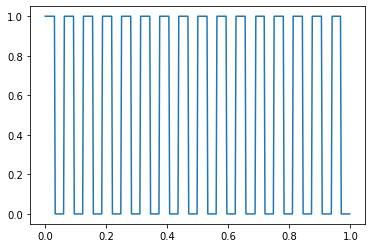

In [366]:
from scipy import signal
import matplotlib.pyplot as plt
t = np.linspace(0, 1, 400, endpoint=False)
y = (signal.square(2 * np.pi * 16 * t)+1)/2
plt.plot(t, y)
#plt.ylim(-2, 2)
